# This same note is in notes.md in the same directory to this jupyter notebook.

## Overview (with a few extension options)

* Regression vs. Classification:
  * **Pros**: regression uses the margin of victory, so a 3–0 and 1–0 are not treated as equally strong wins.
  * **Cons**: soccer scores are **low-count, discrete, noisy, and heavily concentrated near 0**, so plain regression is a bit less natural than classification.
* **Primary regression approach**: predict **goal difference**; *vs.* **Optional stronger extension**: predict the **two team scores separately** with count models, then derive win/draw/loss from those
* Symmetric vs. assymetric threshold

## Models

I used this following set:

1. **Ridge regression**
   Best baseline. Stable for small data, easy to interpret, good when sample size is limited.
2. **Elastic Net / Lasso**
   Useful if we have many correlated engineered features (we probably do because Tony and Oge work on feature engineering) and want some regularization / feature selection.
3. **Random Forest Regressor**
   Captures nonlinearity and interactions without much preprocessing.
4. **XGBoost Regressor**
   Probably the strongest nonlinear candidate, especially since Mingjie already uses XGBoost on the classification side.

That gives us a very nice comparison:

- linear regularized baseline
- sparse/regularized linear variant
- bagged tree model
- boosted tree model

## Evaluation

I used both **regression** metrics and **converted classification** metrics.

### Regression-side metrics

These tell whether the model predicts score margin well:

* **MAE** on goal difference
* **RMSE** on goal difference

I would make **MAE **the main one because soccer score margins are small and MAE is easier to interpret.

### Converted 3-class metrics

After applying threshold tt**t**, compare fairly to Mingjie's classification approach:

* **macro F1**
* **accuracy**
* confusion matrix
* optionally macro recall

This is crucial, because even if regression has decent MAE, it may still map poorly into draw/upset/win classes.

## Comparison with Mingjie's classifier

I used the **same split and same feature matrix entry point** (`fav_df`) and only changed:

* target $y$
* estimator type
* decision rule from continuous output to 3 classes

That makes the comparison clean:

* same preprocessing base
* same temporal split
* same evaluation period
* same engineered features

This is exactly in accordance with the project design of comparing modeling strategies on the same underlying data.

## Potential Weakness

- regression to score difference may under-predict draws

A continuous regressor tends to shrink predictions toward the mean. That can be okay, but it means:

* many predictions may cluster around small positive values
* the threshold may become the main determinant of draw frequency

That is not necessarily bad, but it means threshold tuning is extremely important.

## Better Alternative

### model each team's goals separately

Predict:

* favored goals
* underdog goals

with **Poisson regression** or another count model, then derive:

* predicted goal difference
* predicted class
* even draw probability

Why this is attractive:

* goals are nonnegative counts
* soccer score distributions are low-count
* draw probability emerges more naturally

This is more principled than plain regression on difference.

# Part 1

For Part 1, I did:

- build the regression target
- reuse Mingjie’s `fav_df`
- define the feature matrix
- create the same temporal train/holdout split
- run a few sanity checks on target distribution

I have **not** trained any model yet.

## 0. Paths

In [1]:
# BUILD fav_df (minimal preprocessing block for regression work)
# Based on Mingjie's notebook, but stripped down to only what is needed

import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd


# 0. PATHS -- EDIT THESE IF NEEDED
# I added one more ../ since I created new directory
BASE = Path("../../../")  # <-- change this if needed
DB_PATH = BASE / "data/raw/worldcup/data-sqlite/worldcup.db"
ELO_PATH = BASE / "data/raw/elo_ratings.csv"

assert DB_PATH.is_file(), f"SQLite DB not found: {DB_PATH}"
assert ELO_PATH.is_file(), f"Elo CSV not found: {ELO_PATH}"

## 1. Load Raw Tables

In [2]:
con = sqlite3.connect(DB_PATH)


def _sql(q):
    return pd.read_sql_query(q, con)


matches = _sql("SELECT * FROM matches")
tournaments = _sql("SELECT * FROM tournaments")
teams = _sql("SELECT * FROM teams")
stadiums = _sql("SELECT * FROM stadiums")
team_appearances = _sql("SELECT * FROM team_appearances")
squads = _sql("SELECT * FROM squads")
players = _sql("SELECT * FROM players")
manager_appointments = _sql("SELECT * FROM manager_appointments")
managers = _sql("SELECT * FROM managers")
manager_appearances = _sql("SELECT * FROM manager_appearances")
referee_appearances = _sql("SELECT * FROM referee_appearances")

# Outcome flags used later
mdb = _sql("SELECT match_id, home_team_win, away_team_win, draw FROM matches")

con.close()

elo_raw = pd.read_csv(ELO_PATH)

print("Loaded raw tables:")
print("matches:", matches.shape)
print("tournaments:", tournaments.shape)
print("teams:", teams.shape)
print("team_appearances:", team_appearances.shape)
print("squads:", squads.shape)
print("players:", players.shape)
print("elo_raw:", elo_raw.shape)

Loaded raw tables:
matches: (1248, 28)
tournaments: (30, 17)
teams: (88, 11)
team_appearances: (2496, 17)
squads: (13843, 6)
players: (10401, 12)
elo_raw: (17200, 17)


## 2. Date Parsing + tournament Year Info

In [3]:
tournaments["start_dt"] = pd.to_datetime(
    tournaments["start_date"], unit="D", origin="unix", errors="coerce"
)
matches["match_dt"] = pd.to_datetime(
    matches["match_date"], unit="D", origin="unix", errors="coerce"
)

tourn_year = tournaments[["tournament_id", "year", "host_country", "start_dt"]].copy()
matches = matches.merge(tourn_year, on="tournament_id", how="left", suffixes=("", "_t"))

C:\Users\yiyun\AppData\Local\Temp\ipykernel_20356\2085426931.py:4: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  matches["match_dt"] = pd.to_datetime(


## 3. Base Match Table

In [4]:
base = matches[
    [
        "match_id",
        "tournament_id",
        "year",
        "host_country",
        "home_team_id",
        "away_team_id",
        "match_dt",
        "stage_name",
        "group_name",
        "group_stage",
        "knockout_stage",
        "replayed",
        "replay",
        "stadium_id",
        "home_team_win",
    ]
].copy()

base["y_win"] = base["home_team_win"].astype("Int64").fillna(0).astype(int)

th = teams.rename(columns={c: f"home_{c}" for c in teams.columns if c != "team_id"})
ta = teams.rename(columns={c: f"away_{c}" for c in teams.columns if c != "team_id"})

base = base.merge(th, left_on="home_team_id", right_on="team_id", how="left").drop(
    columns=["team_id"]
)
base = base.merge(ta, left_on="away_team_id", right_on="team_id", how="left").drop(
    columns=["team_id"]
)
base = base.merge(stadiums, on="stadium_id", how="left", suffixes=("", "_stadium"))


def _norm(s):
    return s.astype(str).str.strip().str.lower().str.replace(" ", "", regex=False)


base["feat_same_confederation"] = (
    base["home_confederation_id"] == base["away_confederation_id"]
).astype(int)

base["feat_home_is_host_nation"] = (
    _norm(base["home_team_name"]) == _norm(base["host_country"])
).astype(int)
base["feat_away_is_host_nation"] = (
    _norm(base["away_team_name"]) == _norm(base["host_country"])
).astype(int)

print("\nbase shape after match/team/stadium merge:", base.shape)


base shape after match/team/stadium merge: (1248, 45)


## 4. Historical Team Features

In [5]:
ta_hist = team_appearances.merge(
    tourn_year[["tournament_id", "year"]], on="tournament_id", how="left"
)
ta_hist = ta_hist.merge(
    matches[["match_id", "knockout_stage", "group_stage"]],
    on="match_id",
    how="left",
    suffixes=("", "_m"),
)

ALPHA, BETA = 2.0, 2.0


def shrink_win_rate(w, n, a=ALPHA, b=BETA):
    return (w + a) / (n + a + b) if n > 0 else a / (a + b)


def prior_team_stats(team_id, before_year):
    sub = ta_hist[(ta_hist["team_id"] == team_id) & (ta_hist["year"] < before_year)]
    if sub.empty:
        return dict(
            n_tournaments=0,
            n_matches=0,
            wins=0,
            draws=0,
            losses=0,
            goal_diff_sum=0,
            ko_matches=0,
            ko_wins=0,
            pso_matches=0,
            pso_wins=0,
            et_matches=0,
            tournaments_with_ko_game=0,
        )

    ko = sub[sub["knockout_stage"] == 1]
    pso = sub[sub["penalty_shootout"] == 1]

    return dict(
        n_tournaments=sub["tournament_id"].nunique(),
        n_matches=len(sub),
        wins=int(sub["win"].sum()),
        draws=int(sub["draw"].sum()),
        losses=int(sub["lose"].sum()),
        goal_diff_sum=float((sub["goals_for"] - sub["goals_against"]).sum()),
        ko_matches=len(ko),
        ko_wins=int(ko["win"].sum()),
        pso_matches=len(pso),
        pso_wins=int((pso["penalties_for"] > pso["penalties_against"]).sum()),
        et_matches=int(sub["extra_time"].sum()),
        tournaments_with_ko_game=len(set(ko["tournament_id"].unique())),
    )


years = sorted(base["year"].dropna().unique())
all_tids = pd.unique(
    np.concatenate([base["home_team_id"].values, base["away_team_id"].values])
)

cache = {
    (tid, int(y)): prior_team_stats(tid, int(y)) for tid in all_tids for y in years
}


def attach_hist(df, prefix, team_col):
    rows = [cache[(r[team_col], int(r["year"]))] for _, r in df.iterrows()]
    h = pd.DataFrame(rows).add_prefix(f"{prefix}hist_")
    pfx = f"{prefix}hist_"

    h[f"{pfx}win_rate_shrunk"] = [
        shrink_win_rate(int(w), int(n))
        for w, n in zip(h[f"{pfx}wins"], h[f"{pfx}n_matches"])
    ]
    h[f"{pfx}goal_diff_per_match"] = np.where(
        h[f"{pfx}n_matches"] > 0,
        h[f"{pfx}goal_diff_sum"] / h[f"{pfx}n_matches"],
        np.nan,
    )
    h[f"{pfx}ko_win_rate_shrunk"] = [
        shrink_win_rate(int(kw), int(km))
        for kw, km in zip(h[f"{pfx}ko_wins"], h[f"{pfx}ko_matches"])
    ]
    h[f"{pfx}pso_win_rate_shrunk"] = [
        shrink_win_rate(int(pw), int(pm)) if pm > 0 else np.nan
        for pw, pm in zip(h[f"{pfx}pso_wins"], h[f"{pfx}pso_matches"])
    ]
    h[f"{pfx}et_rate"] = np.where(
        h[f"{pfx}n_matches"] > 0,
        h[f"{pfx}et_matches"] / h[f"{pfx}n_matches"],
        np.nan,
    )
    h[f"{pfx}frac_tournaments_reached_ko"] = np.where(
        h[f"{pfx}n_tournaments"] > 0,
        h[f"{pfx}tournaments_with_ko_game"] / h[f"{pfx}n_tournaments"],
        np.nan,
    )
    return pd.concat([df.reset_index(drop=True), h], axis=1)


base = attach_hist(base, "home_", "home_team_id")
base = attach_hist(base, "away_", "away_team_id")

base["feat_hist_win_rate_diff"] = (
    base["home_hist_win_rate_shrunk"] - base["away_hist_win_rate_shrunk"]
)
base["feat_hist_goal_diff_per_match_diff"] = (
    base["home_hist_goal_diff_per_match"] - base["away_hist_goal_diff_per_match"]
)

print("base shape after historical team stats:", base.shape)

base shape after historical team stats: (1248, 83)


## 5. Win Rate *vs.* Opponent Confederation

In [ ]:
opp_conf = teams[["team_id", "confederation_id"]].rename(
    columns={"team_id": "opponent_id", "confederation_id": "opponent_confederation_id"}
)
ta_oc = ta_hist.merge(opp_conf, on="opponent_id", how="left")


def rate_vs_conf(team_id, before_year, opp_conf_id):
    if pd.isna(opp_conf_id):
        return np.nan
    sub = ta_oc[
        (ta_oc["team_id"] == team_id)
        & (ta_oc["year"] < before_year)
        & (ta_oc["opponent_confederation_id"] == opp_conf_id)
    ]
    return shrink_win_rate(int(sub["win"].sum()), len(sub)) if not sub.empty else np.nan


base["feat_home_hist_win_rate_vs_away_conf"] = [
    rate_vs_conf(h, int(y), c)
    for h, y, c in zip(
        base["home_team_id"], base["year"], base["away_confederation_id"]
    )
]
base["feat_away_hist_win_rate_vs_home_conf"] = [
    rate_vs_conf(a, int(y), c)
    for a, y, c in zip(
        base["away_team_id"], base["year"], base["home_confederation_id"]
    )
]

print("Added confederation matchup features.")

Added confederation matchup features.


## 6. Squad Features

In [7]:
sq = squads.merge(tourn_year[["tournament_id", "year", "start_dt"]], on="tournament_id")
sq = sq.merge(players, on="player_id", how="left")
sq["birth_dt"] = pd.to_datetime(sq["birth_date"], errors="coerce")

pyt = sq[["player_id", "tournament_id", "year"]].drop_duplicates()
prior_rows = []
for (pid, y), g in pyt.groupby(["player_id", "year"]):
    n_prior = pyt[(pyt["player_id"] == pid) & (pyt["year"] < y)][
        "tournament_id"
    ].nunique()
    prior_rows.append({"player_id": pid, "year": y, "prior_wc_played": n_prior})
prior_wc = pd.DataFrame(prior_rows)

sq = sq.merge(prior_wc, on=["player_id", "year"], how="left")
sq["age_at_tournament"] = (sq["start_dt"] - sq["birth_dt"]).dt.days / 365.25

for col in ["goal_keeper", "defender", "midfielder", "forward"]:
    sq[col] = sq[col].fillna(0).astype(int)


def squad_row(g):
    return dict(
        n_players=len(g),
        age_mean=g["age_at_tournament"].mean(),
        age_median=g["age_at_tournament"].median(),
        age_std=g["age_at_tournament"].std(),
        age_min=g["age_at_tournament"].min(),
        age_max=g["age_at_tournament"].max(),
        n_gk=int(g["goal_keeper"].sum()),
        n_df=int(g["defender"].sum()),
        n_mf=int(g["midfielder"].sum()),
        n_fw=int(g["forward"].sum()),
        prior_wc_mean=g["prior_wc_played"].mean(),
        prior_wc_median=g["prior_wc_played"].median(),
        share_any_prior_wc=(g["prior_wc_played"] > 0).mean(),
        share_ge2_prior_wc=(g["prior_wc_played"] >= 2).mean(),
    )


squad_records = [
    {"tournament_id": tid, "team_id": tmid, **squad_row(g)}
    for (tid, tmid), g in sq.groupby(["tournament_id", "team_id"])
]
squad_feats = pd.DataFrame(squad_records)

overlap_records = []
for team_id, g in sq.groupby("team_id"):
    g = g.sort_values("year")
    years_order = g["year"].unique()
    prev_players = None

    for y in years_order:
        cur = set(g.loc[g["year"] == y, "player_id"].unique())
        if prev_players is not None:
            inter = len(cur & prev_players)
            uni = len(cur | prev_players)
            overlap_records.append(
                dict(
                    team_id=team_id,
                    year=y,
                    squad_jaccard_vs_prev_wc=inter / uni if uni else np.nan,
                    squad_overlap_count_vs_prev_wc=inter,
                )
            )
        prev_players = cur

overlap_df = pd.DataFrame(overlap_records)

squad_feats = squad_feats.merge(
    tourn_year[["tournament_id", "year"]], on="tournament_id", how="left"
)
squad_feats = squad_feats.merge(overlap_df, on=["team_id", "year"], how="left")


def _squad_side(sf, prefix, team_col):
    sf2 = sf.rename(
        columns={
            c: f"{prefix}squad_{c}"
            for c in sf.columns
            if c not in ("tournament_id", "team_id", "year")
        }
    )
    sf2 = sf2.rename(columns={"team_id": team_col})
    sf2 = sf2.drop(columns=["year"], errors="ignore")
    return sf2


base = base.merge(
    _squad_side(squad_feats, "home_", "home_team_id"),
    on=["tournament_id", "home_team_id"],
    how="left",
)
base = base.merge(
    _squad_side(squad_feats, "away_", "away_team_id"),
    on=["tournament_id", "away_team_id"],
    how="left",
)

base["feat_squad_age_mean_diff"] = (
    base["home_squad_age_mean"] - base["away_squad_age_mean"]
)
base["feat_squad_prior_wc_mean_diff"] = (
    base["home_squad_prior_wc_mean"] - base["away_squad_prior_wc_mean"]
)

print("base shape after squad features:", base.shape)

base shape after squad features: (1248, 119)


## 7. Manager Features

In [8]:
ma = manager_appointments.merge(
    tourn_year[["tournament_id", "year"]], on="tournament_id"
)
ma = ma.merge(managers, on="manager_id", how="left")
ma_pick = ma.sort_values("manager_id").drop_duplicates(
    subset=["tournament_id", "team_id"], keep="first"
)


def _mgr_side(prefix, side_col):
    cols = {
        "manager_id": f"{prefix}manager_id",
        "country_name": f"{prefix}manager_country_name",
        "female": f"{prefix}manager_female",
    }
    df = ma_pick.rename(columns=cols)
    df = df.rename(columns={"team_id": side_col})
    return df[
        [
            "tournament_id",
            side_col,
            f"{prefix}manager_id",
            f"{prefix}manager_country_name",
            f"{prefix}manager_female",
        ]
    ]


base = base.merge(
    _mgr_side("home_", "home_team_id"),
    on=["tournament_id", "home_team_id"],
    how="left",
)
base = base.merge(
    _mgr_side("away_", "away_team_id"),
    on=["tournament_id", "away_team_id"],
    how="left",
)

base["feat_home_manager_local"] = (
    _norm(base["home_manager_country_name"]) == _norm(base["home_team_name"])
).astype(int)
base["feat_away_manager_local"] = (
    _norm(base["away_manager_country_name"]) == _norm(base["away_team_name"])
).astype(int)

mgr_tourneys = (
    ma_pick[["manager_id", "tournament_id", "year"]]
    .drop_duplicates()
    .sort_values(["manager_id", "year"])
)

mgr_prior_rows = []
for mid, g in mgr_tourneys.groupby("manager_id"):
    for i, (_, r) in enumerate(g.iterrows()):
        mgr_prior_rows.append(
            {
                "manager_id": mid,
                "tournament_id": r["tournament_id"],
                "mgr_n_prior_wc": i,
            }
        )
mgr_prior_df = pd.DataFrame(mgr_prior_rows)

for side in ["home", "away"]:
    tmp = mgr_prior_df.rename(
        columns={
            "manager_id": f"{side}_manager_id",
            "mgr_n_prior_wc": f"{side}_mgr_n_prior_wc",
        }
    )
    base = base.merge(
        tmp[[f"{side}_manager_id", "tournament_id", f"{side}_mgr_n_prior_wc"]],
        on=[f"{side}_manager_id", "tournament_id"],
        how="left",
    )

mapp = manager_appearances.merge(
    tourn_year[["tournament_id", "year"]], on="tournament_id"
).merge(
    team_appearances[["tournament_id", "match_id", "team_id", "win"]],
    on=["tournament_id", "match_id", "team_id"],
    how="left",
)


def mgr_hist_win_rate(manager_id, before_year):
    sub = mapp[(mapp["manager_id"] == manager_id) & (mapp["year"] < before_year)]
    sub = sub.dropna(subset=["win"])
    return shrink_win_rate(int(sub["win"].sum()), len(sub)) if not sub.empty else np.nan


base["feat_home_mgr_hist_win_rate_shrunk"] = [
    mgr_hist_win_rate(m, int(y)) if pd.notna(m) else np.nan
    for m, y in zip(base["home_manager_id"], base["year"])
]
base["feat_away_mgr_hist_win_rate_shrunk"] = [
    mgr_hist_win_rate(m, int(y)) if pd.notna(m) else np.nan
    for m, y in zip(base["away_manager_id"], base["year"])
]

streak_rows = []
for (mid, tid), g in ma_pick.sort_values("year").groupby(["manager_id", "team_id"]):
    g = g.drop_duplicates(subset=["tournament_id", "year"]).sort_values("year")
    yrs = g["year"].astype(int).tolist()
    tids = g["tournament_id"].tolist()
    run = 0
    for i, y in enumerate(yrs):
        run = (run + 1) if (i == 0 or y - yrs[i - 1] in (1, 4)) else 1
        streak_rows.append(
            {
                "manager_id": mid,
                "team_id": tid,
                "tournament_id": tids[i],
                "mgr_consecutive_wc_with_team": run,
            }
        )
streak_df = pd.DataFrame(streak_rows)

for side in ["home", "away"]:
    tmp = streak_df.rename(
        columns={
            "manager_id": f"{side}_manager_id",
            "team_id": f"{side}_team_id",
            "mgr_consecutive_wc_with_team": f"{side}_mgr_consecutive_wc_with_team",
        }
    )
    base = base.merge(
        tmp[
            [
                f"{side}_manager_id",
                f"{side}_team_id",
                "tournament_id",
                f"{side}_mgr_consecutive_wc_with_team",
            ]
        ],
        on=[f"{side}_manager_id", f"{side}_team_id", "tournament_id"],
        how="left",
    )

print("base shape after manager features:", base.shape)

base shape after manager features: (1248, 133)


## 8. Schedule / Context Features

In [9]:
sched = matches[
    ["match_id", "tournament_id", "home_team_id", "away_team_id", "match_dt", "year"]
].copy()

long_sched = pd.concat(
    [
        sched.rename(
            columns={"home_team_id": "team_id", "away_team_id": "opponent_id"}
        ),
        sched.rename(
            columns={"away_team_id": "team_id", "home_team_id": "opponent_id"}
        ),
    ],
    ignore_index=True,
).sort_values(["tournament_id", "team_id", "match_dt", "match_id"])

long_sched["prev_match_dt"] = long_sched.groupby(["tournament_id", "team_id"])[
    "match_dt"
].shift(1)
long_sched["rest_days"] = (long_sched["match_dt"] - long_sched["prev_match_dt"]).dt.days

for side in ["home", "away"]:
    rest = long_sched.rename(
        columns={
            "rest_days": f"{side}_rest_days_since_prev_match",
            "team_id": f"{side}_team_id",
        }
    )[[f"match_id", f"{side}_team_id", f"{side}_rest_days_since_prev_match"]]

    base = base.merge(rest, on=["match_id", f"{side}_team_id"], how="left")

base["feat_rest_days_diff"] = (
    base["home_rest_days_since_prev_match"] - base["away_rest_days_since_prev_match"]
)

nref = referee_appearances.groupby("match_id").size().reset_index(name="n_referees")
base = base.merge(nref, on="match_id", how="left")
base["n_referees"] = base["n_referees"].fillna(0).astype(int)

print("base shape after schedule/context features:", base.shape)

base shape after schedule/context features: (1248, 137)


## 9. Build `df_all`

In [10]:
ID_COLS = ["match_id", "tournament_id", "year", "home_team_id", "away_team_id"]
LABEL = "y_win"

numeric_hist = [
    c for c in base.columns if c.startswith("home_hist_") or c.startswith("away_hist_")
]
numeric_squad = [
    c
    for c in base.columns
    if c.startswith("home_squad_") or c.startswith("away_squad_")
]
feat_prefixed = [c for c in base.columns if c.startswith("feat_")]
mgr_numeric = [
    "home_mgr_n_prior_wc",
    "away_mgr_n_prior_wc",
    "feat_home_mgr_hist_win_rate_shrunk",
    "feat_away_mgr_hist_win_rate_shrunk",
    "home_mgr_consecutive_wc_with_team",
    "away_mgr_consecutive_wc_with_team",
    "feat_home_manager_local",
    "feat_away_manager_local",
]
schedule_ctx = [
    "group_stage",
    "knockout_stage",
    "replayed",
    "replay",
    "stadium_capacity",
    "home_rest_days_since_prev_match",
    "away_rest_days_since_prev_match",
    "n_referees",
]

FEATURE_COLS = sorted(
    set(numeric_hist + numeric_squad + feat_prefixed + mgr_numeric + schedule_ctx)
)
EXPORT_COLS = ID_COLS + [LABEL] + FEATURE_COLS + ["stage_name", "group_name"]
EXTRA = ["home_team_name", "away_team_name"]

df_all = base[[c for c in EXPORT_COLS + EXTRA if c in base.columns]].copy()
print("df_all shape:", df_all.shape)

df_all shape: (1248, 104)


## 10. Restrict to Men's World Cups + Join ELO + Build `y3`

In [ ]:
MENS_WC_YEARS = [2002, 2006, 2010, 2014, 2018, 2022]

men = df_all[df_all["year"].isin(MENS_WC_YEARS)].copy()

NAME_MAP = {
    "Czech Republic": "Czechia",
    "Republic of Ireland": "Ireland",
    "West Germany": "Germany",
    "Serbia and Montenegro": "Serbia",
}

team_lookup = teams[["team_id", "team_name"]].copy()
team_lookup["elo_name"] = team_lookup["team_name"].map(lambda x: NAME_MAP.get(x, x))
elo_yr = elo_raw[["year", "team", "rating"]].rename(columns={"team": "elo_name"})

for side in ["home", "away"]:
    tmp = (
        men[[f"{side}_team_id", "year"]]
        .merge(
            team_lookup[["team_id", "elo_name"]],
            left_on=f"{side}_team_id",
            right_on="team_id",
            how="left",
        )
        .merge(elo_yr, on=["elo_name", "year"], how="left")
    )
    men[f"{side}_elo"] = tmp["rating"].values

men = men.dropna(subset=["home_elo", "away_elo"]).copy()
men["fav_side"] = np.where(men["home_elo"] >= men["away_elo"], "home", "away")

mdb["home_result"] = np.select(
    [mdb["home_team_win"] == 1, mdb["draw"] == 1],
    ["W", "D"],
    default="L",
)
mdb["home_result"] = mdb["home_result"].where(
    mdb[["home_team_win", "draw"]].notna().all(axis=1),
    other=None,
)

men = men.merge(mdb[["match_id", "home_result"]], on="match_id", how="left")
men = men.dropna(subset=["home_result"]).copy()

# 3-class label used by Mingjie
# 2 = favored wins, 1 = draw, 0 = favored loses
men["y3"] = np.select(
    [
        (men["fav_side"] == "home") & (men["home_result"] == "W"),
        (men["fav_side"] == "away") & (men["home_result"] == "L"),
        men["home_result"] == "D",
    ],
    [2, 2, 1],
    default=0,
)

print("\nmen shape after Elo join:", men.shape)
print("y3 distribution:")
print(men["y3"].value_counts().sort_index())


men shape after Elo join: (384, 109)
y3 distribution:
y3
0     63
1     67
2    254
Name: count, dtype: int64


## 11. Build `fav_df`

In [12]:
id_cols = {
    "match_id",
    "year",
    "home_team_id",
    "away_team_id",
    "home_team_name",
    "away_team_name",
    "match_dt",
    "tournament_id",
    "stage_name",
    "group_name",
    "group",
    "round",
    "home_elo",
    "away_elo",
    "fav_side",
    "home_result",
}

non_feature = {"y_win", "y3", "home_squad_year", "away_squad_year"}
skip = id_cols | non_feature

orig_num = [
    c for c in men.columns if c not in skip and pd.api.types.is_numeric_dtype(men[c])
]
home_cols = [c for c in orig_num if c.startswith("home_")]
other_num = [c for c in orig_num if not c.startswith(("home_", "away_"))]

fav_df = men.copy()
away_fav_mask = men["fav_side"] == "away"

for hcol in home_cols:
    acol = "away_" + hcol[5:]
    if acol not in men.columns:
        continue

    fav_df["fav_" + hcol[5:]] = np.where(away_fav_mask, men[acol], men[hcol])
    fav_df["und_" + hcol[5:]] = np.where(away_fav_mask, men[hcol], men[acol])

fav_df["elo_gap"] = np.where(
    men["fav_side"] == "home",
    men["home_elo"] - men["away_elo"],
    men["away_elo"] - men["home_elo"],
)
fav_df["fav_elo"] = np.where(
    men["fav_side"] == "home", men["home_elo"], men["away_elo"]
)
fav_df["und_elo"] = np.where(
    men["fav_side"] == "home", men["away_elo"], men["home_elo"]
)

feat_other = [c for c in other_num if c in fav_df.columns]
fav_num_cols = (
    [
        c
        for c in fav_df.columns
        if c.startswith(("fav_", "und_")) and pd.api.types.is_numeric_dtype(fav_df[c])
    ]
    + ["elo_gap"]
    + feat_other
)

X_all = fav_df[fav_num_cols].copy()
y_all = fav_df["y3"].values

print("\nDone.")
print("fav_df shape:", fav_df.shape)
print("X_all shape:", X_all.shape)
print("Unique classes in y_all:", np.unique(y_all))
print("\nFirst 20 columns of fav_df:")
print(fav_df.columns[:20].tolist())


Done.
fav_df shape: (384, 186)
X_all shape: (384, 97)
Unique classes in y_all: [0 1 2]

First 20 columns of fav_df:
['match_id', 'tournament_id', 'year', 'home_team_id', 'away_team_id', 'y_win', 'away_hist_draws', 'away_hist_et_matches', 'away_hist_et_rate', 'away_hist_frac_tournaments_reached_ko', 'away_hist_goal_diff_per_match', 'away_hist_goal_diff_sum', 'away_hist_ko_matches', 'away_hist_ko_win_rate_shrunk', 'away_hist_ko_wins', 'away_hist_losses', 'away_hist_n_matches', 'away_hist_n_tournaments', 'away_hist_pso_matches', 'away_hist_pso_win_rate_shrunk']


# Part 2

This block will:

1. detect the raw home/away score columns from `matches`
2. merge them into `fav_df`
3. build:
    - `fav_goals`
    - `und_goals`
    - `goal_diff = fav_goals - und_goals`
4. build `X`, `y`
5. create the same temporal split:
    - train: 2002–2014
    - holdout: 2018 + 2022
6. print sanity checks

Searching for score columns in matches...
Detected home score column: home_team_score
Detected away score column: away_team_score

After merging score columns:
df_reg shape: (384, 188)
Missing values in detected score columns:
home_team_score    0
away_team_score    0
dtype: int64

Agreement between reconstructed y3 and Mingjie's y3: 0.9453

Mismatches found:
      match_id  year fav_side  y3  y3_from_goal_diff  fav_goals  und_goals
51   M-2002-52  2002     home   2                  1          1          1
58   M-2002-59  2002     home   0                  1          0          0
117  M-2006-54  2006     home   0                  1          0          0
120  M-2006-57  2006     away   0                  1          1          1
122  M-2006-59  2006     home   0                  1          0          0
127  M-2006-64  2006     away   0                  1          1          1
182  M-2010-55  2010     away   0                  1          0          0
185  M-2010-58  2010     home   2     

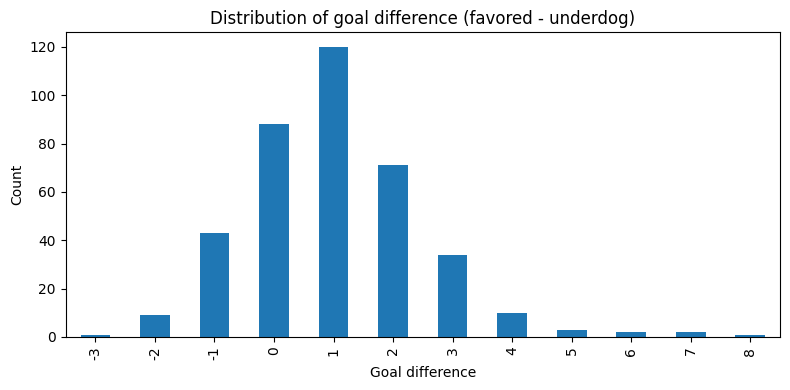

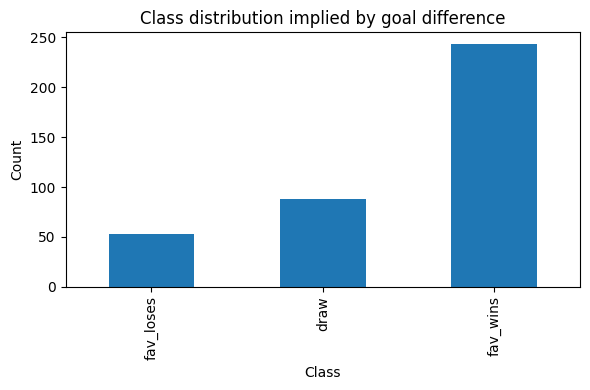


Part 2 completed successfully.


In [ ]:
# ============================================================
# PART 2 — Create regression target and temporal split
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# 1. Detect score columns in matches
# ----------------------------
print("Searching for score columns in matches...")

candidate_home_score_cols = [
    "home_score",
    "home_team_score",
    "home_goals",
    "home_team_goals",
    "score_home",
]
candidate_away_score_cols = [
    "away_score",
    "away_team_score",
    "away_goals",
    "away_team_goals",
    "score_away",
]

home_score_col = next(
    (c for c in candidate_home_score_cols if c in matches.columns), None
)
away_score_col = next(
    (c for c in candidate_away_score_cols if c in matches.columns), None
)

print("Detected home score column:", home_score_col)
print("Detected away score column:", away_score_col)

if home_score_col is None or away_score_col is None:
    print("\nCould not auto-detect score columns.")
    print("Columns in matches containing 'score' or 'goal':")
    possible = [
        c for c in matches.columns if ("score" in c.lower()) or ("goal" in c.lower())
    ]
    print(possible)
    raise ValueError(
        "Please inspect the printed list and manually set home_score_col / away_score_col."
    )

# ----------------------------
# 2. Merge raw match scores into fav_df
# ----------------------------
score_df = matches[["match_id", home_score_col, away_score_col]].copy()

df_reg = fav_df.merge(score_df, on="match_id", how="left")

print("\nAfter merging score columns:")
print("df_reg shape:", df_reg.shape)

missing_scores = df_reg[[home_score_col, away_score_col]].isna().sum()
print("Missing values in detected score columns:")
print(missing_scores)

# ----------------------------
# 3. Build favored / underdog goals
# ----------------------------
df_reg["fav_goals"] = np.where(
    df_reg["fav_side"] == "home",
    df_reg[home_score_col],
    df_reg[away_score_col],
)

df_reg["und_goals"] = np.where(
    df_reg["fav_side"] == "home",
    df_reg[away_score_col],
    df_reg[home_score_col],
)

df_reg["goal_diff"] = df_reg["fav_goals"] - df_reg["und_goals"]


# ----------------------------
# 4. Sanity-check against Mingjie's y3 labels
#    y3: 2=fav wins, 1=draw, 0=fav loses
# ----------------------------
def diff_to_y3(x):
    if x > 0:
        return 2
    elif x == 0:
        return 1
    else:
        return 0


df_reg["y3_from_goal_diff"] = df_reg["goal_diff"].apply(diff_to_y3)

agreement = (df_reg["y3_from_goal_diff"] == df_reg["y3"]).mean()
print("\nAgreement between reconstructed y3 and Mingjie's y3:", round(agreement, 4))

if agreement < 1.0:
    mismatch = df_reg.loc[
        df_reg["y3_from_goal_diff"] != df_reg["y3"],
        [
            "match_id",
            "year",
            "fav_side",
            "y3",
            "y3_from_goal_diff",
            "fav_goals",
            "und_goals",
        ],
    ]
    print("\nMismatches found:")
    print(mismatch.head(20))
else:
    print("Perfect agreement. Target construction looks correct.")


# ----------------------------
# 5. Build human-readable class from goal_diff
# ----------------------------
def diff_to_class(x):
    if x > 0:
        return "fav_wins"
    elif x < 0:
        return "fav_loses"
    else:
        return "draw"


df_reg["true_class"] = df_reg["goal_diff"].apply(diff_to_class)

print("\nGoal difference summary:")
print(df_reg["goal_diff"].describe())

print("\nGoal difference value counts:")
print(df_reg["goal_diff"].value_counts().sort_index())

print("\nTrue class distribution from goal_diff:")
print(df_reg["true_class"].value_counts().sort_index())

# ----------------------------
# 6. Build regression feature matrix
#    Use the same favored-perspective numeric features as before
# ----------------------------
# Reuse the numeric feature columns already defined earlier if available.
if "fav_num_cols" not in globals():
    fav_num_cols = [
        c
        for c in fav_df.columns
        if c.startswith(("fav_", "und_")) and pd.api.types.is_numeric_dtype(fav_df[c])
    ]
    feat_other = [
        c
        for c in fav_df.columns
        if (not c.startswith(("home_", "away_", "fav_", "und_")))
        and pd.api.types.is_numeric_dtype(fav_df[c])
        and c not in {"y_win", "y3"}
    ]
    if "elo_gap" in fav_df.columns and "elo_gap" not in fav_num_cols:
        fav_num_cols = fav_num_cols + ["elo_gap"]
    fav_num_cols = list(dict.fromkeys(fav_num_cols + feat_other))

X = df_reg[fav_num_cols].copy()
y = df_reg["goal_diff"].copy()
years = df_reg["year"].copy()

print("\nRegression design matrices:")
print("X shape:", X.shape)
print("y shape:", y.shape)

# ----------------------------
# 7. Temporal split
# ----------------------------
train_mask = years < 2018
holdout_mask = years.isin([2018, 2022])

X_train = X.loc[train_mask].reset_index(drop=True)
y_train = y.loc[train_mask].reset_index(drop=True)
year_train = years.loc[train_mask].reset_index(drop=True)

X_holdout = X.loc[holdout_mask].reset_index(drop=True)
y_holdout = y.loc[holdout_mask].reset_index(drop=True)
year_holdout = years.loc[holdout_mask].reset_index(drop=True)

df_train = df_reg.loc[train_mask].reset_index(drop=True)
df_holdout = df_reg.loc[holdout_mask].reset_index(drop=True)

print("\nTemporal split summary:")
print("Train years:", sorted(year_train.unique()))
print("Holdout years:", sorted(year_holdout.unique()))
print("Train size:", len(X_train))
print("Holdout size:", len(X_holdout))

print("\nTrain goal_diff distribution:")
print(y_train.value_counts().sort_index())

print("\nHoldout goal_diff distribution:")
print(y_holdout.value_counts().sort_index())

print("\nTrain class distribution:")
print(df_train["true_class"].value_counts().sort_index())

print("\nHoldout class distribution:")
print(df_holdout["true_class"].value_counts().sort_index())

# ----------------------------
# 8. Missingness check
# ----------------------------
missing_rate = X_train.isna().mean().sort_values(ascending=False)

print("\nTop 20 features by missing rate in X_train:")
print(missing_rate.head(20))

# ----------------------------
# 9. Plot target distribution
# ----------------------------
plt.figure(figsize=(8, 4))
df_reg["goal_diff"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of goal difference (favored - underdog)")
plt.xlabel("Goal difference")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
df_reg["true_class"].value_counts().reindex(["fav_loses", "draw", "fav_wins"]).plot(
    kind="bar"
)
plt.title("Class distribution implied by goal difference")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# ----------------------------
# 10. Save objects for next step
# ----------------------------
regression_objects = {
    "df_reg": df_reg,
    "X": X,
    "y": y,
    "years": years,
    "X_train": X_train,
    "y_train": y_train,
    "year_train": year_train,
    "X_holdout": X_holdout,
    "y_holdout": y_holdout,
    "year_holdout": year_holdout,
    "df_train": df_train,
    "df_holdout": df_holdout,
    "home_score_col": home_score_col,
    "away_score_col": away_score_col,
}

print("\nPart 2 completed successfully.")

## Interpretation

The overall target construction looks sensible:

- goal difference is centered around small positive values
- draws are common (`88 / 384`)
- favored wins dominate (`243 / 384`)
- the train/holdout split is exactly what we wanted: `256 / 128`

The histograms also look reasonable for soccer:

- most matches are between -1 and +2
- 0 and 1 are the two biggest masses
- large margins are rare, as expected

The 0.9453 agreement is almost certainly because of **penalty-shootout matches**. Because in every mismatch we showed here, the score difference is `0`, but Mingjie’s `y3` is sometimes win/loss rather than draw. That happens when:

- the match score is tied after regular time / extra time
- but the official advancement outcome is decided by penalties

So our regression target:

$$\text{goal\_diff} = \text{fav goals} - \text{und goals}$$

cannot represent shootout winners, because penalties do not show up as a normal score margin.

## Regression Design

Therefore, for the **score-difference regression experiment**, I decide to **drop penalty shootout matches from the regression dataset** because:

- our target is score difference
- shootout-decided matches have goal_diff = 0
- but their final outcome is not a draw in Mingjie’s label definition
- leaving them in will create a conceptual mismatch between target and label mapping

This is the statistically clean choice.

If we keep them in, then one of the following must happen:

1. predict `goal_diff = 0` and call it draw
    - then this disagrees with Mingjie’s label on shootout matches
2. predict `goal_diff = 0` but somehow map it to win/loss
    - impossible from score difference alone

So for a clean regression analysis, penalty shootouts should be excluded.

# Part 2.5 Filter out Penalty-shootout Matches

In [ ]:
# ============================================================
# PART 2.5 — Remove penalty-shootout matches for regression
# ============================================================

import numpy as np
import pandas as pd

# ----------------------------
# 1. Detect penalty-shootout column in matches
# ----------------------------
candidate_pso_cols = [
    "penalty_shootout",
    "penalties",
    "decided_by_penalties",
    "penalty_shoot_out",
]

pso_col = next((c for c in candidate_pso_cols if c in matches.columns), None)

print("Detected penalty-shootout column:", pso_col)

if pso_col is None:
    print("\nCould not auto-detect a penalty-shootout column in matches.")
    print("Columns in matches containing 'pen' or 'shoot':")
    possible = [
        c for c in matches.columns if ("pen" in c.lower()) or ("shoot" in c.lower())
    ]
    print(possible)
    raise ValueError("Please inspect the printed columns and manually set pso_col.")

# ----------------------------
# 2. Merge penalty-shootout flag into df_reg
# ----------------------------
pso_df = matches[["match_id", pso_col]].copy()
df_reg2 = df_reg.merge(pso_df, on="match_id", how="left", suffixes=("", "_pso"))

print("\nPenalty-shootout flag distribution:")
print(df_reg2[pso_col].value_counts(dropna=False))

# ----------------------------
# 3. Remove shootout matches
# ----------------------------
# Treat 1/True as shootout matches. Everything else stays.
keep_mask = ~(df_reg2[pso_col].fillna(0).astype(int) == 1)
df_reg_clean = df_reg2.loc[keep_mask].reset_index(drop=True)

print("\nShapes:")
print("Before removing shootouts:", df_reg2.shape)
print("After removing shootouts :", df_reg_clean.shape)
print("Dropped rows:", len(df_reg2) - len(df_reg_clean))

# ----------------------------
# 4. Rebuild train/holdout split
# ----------------------------
X_clean = df_reg_clean[fav_num_cols].copy()
y_clean = df_reg_clean["goal_diff"].copy()
years_clean = df_reg_clean["year"].copy()

train_mask_clean = years_clean < 2018
holdout_mask_clean = years_clean.isin([2018, 2022])

X_train = X_clean.loc[train_mask_clean].reset_index(drop=True)
y_train = y_clean.loc[train_mask_clean].reset_index(drop=True)
year_train = years_clean.loc[train_mask_clean].reset_index(drop=True)

X_holdout = X_clean.loc[holdout_mask_clean].reset_index(drop=True)
y_holdout = y_clean.loc[holdout_mask_clean].reset_index(drop=True)
year_holdout = years_clean.loc[holdout_mask_clean].reset_index(drop=True)

df_train = df_reg_clean.loc[train_mask_clean].reset_index(drop=True)
df_holdout = df_reg_clean.loc[holdout_mask_clean].reset_index(drop=True)

print("\nClean split summary:")
print("Train size:", len(X_train))
print("Holdout size:", len(X_holdout))

print("\nTrain goal_diff distribution:")
print(y_train.value_counts().sort_index())

print("\nHoldout goal_diff distribution:")
print(y_holdout.value_counts().sort_index())


# ----------------------------
# 5. Check class agreement again
# ----------------------------
def diff_to_y3(x):
    if x > 0:
        return 2
    elif x == 0:
        return 1
    else:
        return 0


df_reg_clean["y3_from_goal_diff"] = df_reg_clean["goal_diff"].apply(diff_to_y3)
agreement_clean = (df_reg_clean["y3_from_goal_diff"] == df_reg_clean["y3"]).mean()

print("\nAgreement after removing shootouts:", round(agreement_clean, 4))

# ----------------------------
# 6. Missingness check again
# ----------------------------
missing_rate_clean = X_train.isna().mean().sort_values(ascending=False)

print("\nTop 20 missing-rate features after shootout filtering:")
print(missing_rate_clean.head(20))

# ----------------------------
# 7. Save cleaned objects
# ----------------------------
regression_objects_clean = {
    "df_reg_clean": df_reg_clean,
    "X_train": X_train,
    "y_train": y_train,
    "year_train": year_train,
    "X_holdout": X_holdout,
    "y_holdout": y_holdout,
    "year_holdout": year_holdout,
    "df_train": df_train,
    "df_holdout": df_holdout,
    "pso_col": pso_col,
}

print("\nPart 2.5 completed successfully.")

Detected penalty-shootout column: penalty_shootout

Penalty-shootout flag distribution:
penalty_shootout
0    363
1     21
Name: count, dtype: int64

Shapes:
Before removing shootouts: (384, 194)
After removing shootouts : (363, 194)
Dropped rows: 21

Clean split summary:
Train size: 244
Holdout size: 119

Train goal_diff distribution:
goal_diff
-3     1
-2     7
-1    25
 0    48
 1    83
 2    45
 3    22
 4     9
 6     2
 7     1
 8     1
Name: count, dtype: int64

Holdout goal_diff distribution:
goal_diff
-2     2
-1    18
 0    19
 1    37
 2    26
 3    12
 4     1
 5     3
 7     1
Name: count, dtype: int64

Agreement after removing shootouts: 1.0

Top 20 missing-rate features after shootout filtering:
und_hist_pso_win_rate_shrunk                0.713115
feat_away_mgr_hist_win_rate_shrunk          0.700820
feat_home_mgr_hist_win_rate_shrunk          0.696721
fav_hist_pso_win_rate_shrunk                0.360656
fav_rest_days_since_prev_match              0.262295
und_rest_days_s

This is now clean.

The important part is:

- `21` penalty-shootout matches removed
- agreement is now **1.0**
- training set is `244` matches
- holdout is `119` matches

That is exactly what we want for a coherent score-difference regression setup.

# Part 3: First Baseline Regression Models

For this step, let’s keep it simple and disciplined.

We will run:

1. **DummyRegressor** as a naive benchmark
2. **Ridge regression** as the first real model

We will evaluate with:

- **LOTO CV by World Cup year** on training set
- **MAE**
- **RMSE**
- final **holdout MAE / RMSE**

We are **not** doing thresholding yet.
This step is only about continuous regression quality.

Train shape: (244, 97) (244,)
Holdout shape: (119, 97) (119,)
Training years: [np.int64(2002), np.int64(2006), np.int64(2010), np.int64(2014)]

DummyRegressor LOTO CV results:
   fold val_year       mae      rmse  pred_mean
0     1   [2002]  1.271889  1.702125   1.148352
1     2   [2006]  1.052536  1.444452   0.994565
2     3   [2010]  0.953917  1.419267   1.071429
3     4   [2014]  1.132971  1.583555   1.048913

DummyRegressor mean CV metrics:
mae     1.102828
rmse    1.537350
dtype: float64

DummyRegressor holdout metrics:
{'holdout_mae': 1.127428020388483, 'holdout_rmse': 1.520725763806749, 'holdout_pred_mean': 1.0655737704918034}

Best Ridge alpha:
{'model__alpha': 100.0}
Best Ridge CV MAE: 1.1608286080386938

Ridge LOTO CV results:
   fold val_year       mae      rmse  pred_mean  pred_std
0     1   [2002]  1.196391  1.622967   0.944931  0.478804
1     2   [2006]  1.123812  1.516478   0.850745  0.626943
2     3   [2010]  1.037697  1.468814   1.113786  0.701210
3     4   [2014]  1.2

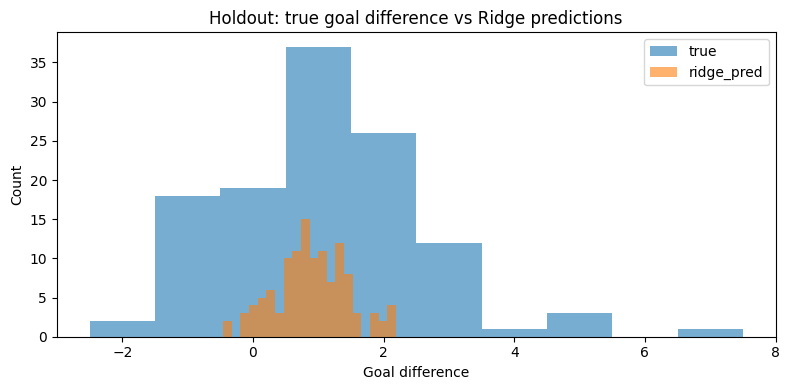

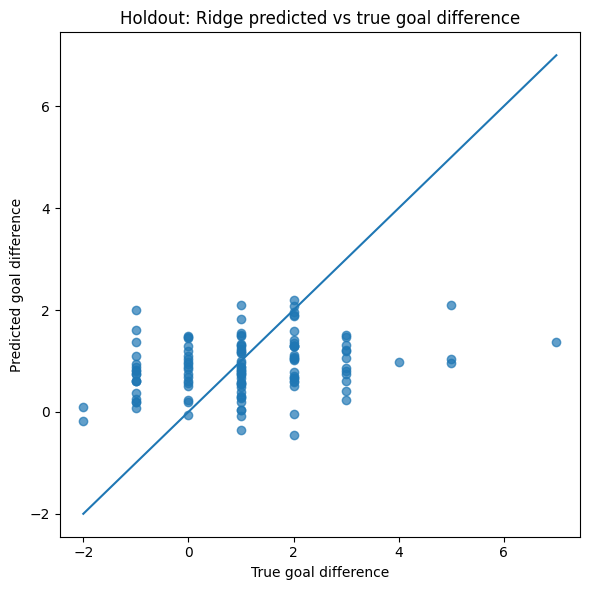


Part 3 completed successfully.


In [ ]:
# ============================================================
# PART 3 — Dummy baseline + Ridge regression
# Continuous evaluation only: MAE / RMSE
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import LeaveOneGroupOut, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# ----------------------------
# 1. Pull cleaned objects
# ----------------------------
if "regression_objects_clean" not in globals():
    raise ValueError("regression_objects_clean not found. Please run Part 2.5 first.")

X_train = regression_objects_clean["X_train"].copy()
y_train = regression_objects_clean["y_train"].copy()
year_train = regression_objects_clean["year_train"].copy()

X_holdout = regression_objects_clean["X_holdout"].copy()
y_holdout = regression_objects_clean["y_holdout"].copy()
year_holdout = regression_objects_clean["year_holdout"].copy()

print("Train shape:", X_train.shape, y_train.shape)
print("Holdout shape:", X_holdout.shape, y_holdout.shape)
print("Training years:", sorted(pd.Series(year_train).unique()))

# ----------------------------
# 2. Define CV
# ----------------------------
logo = LeaveOneGroupOut()

# ----------------------------
# 3. Dummy benchmark
# ----------------------------
dummy_pipe = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DummyRegressor(strategy="mean")),
    ]
)

dummy_cv_rows = []

for fold, (tr_idx, va_idx) in enumerate(
    logo.split(X_train, y_train, groups=year_train), start=1
):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
    val_year = sorted(pd.Series(year_train.iloc[va_idx]).unique().tolist())

    dummy_model = clone(dummy_pipe)
    dummy_model.fit(X_tr, y_tr)
    pred_va = dummy_model.predict(X_va)

    mae = mean_absolute_error(y_va, pred_va)
    rmse = mean_squared_error(y_va, pred_va) ** 0.5

    dummy_cv_rows.append(
        {
            "fold": fold,
            "val_year": val_year,
            "mae": mae,
            "rmse": rmse,
            "pred_mean": float(np.mean(pred_va)),
        }
    )

dummy_cv = pd.DataFrame(dummy_cv_rows)

print("\nDummyRegressor LOTO CV results:")
print(dummy_cv)

print("\nDummyRegressor mean CV metrics:")
print(dummy_cv[["mae", "rmse"]].mean())

# Fit dummy on full train and evaluate holdout
dummy_full = clone(dummy_pipe)
dummy_full.fit(X_train, y_train)
dummy_holdout_pred = dummy_full.predict(X_holdout)

dummy_holdout_mae = mean_absolute_error(y_holdout, dummy_holdout_pred)
dummy_holdout_rmse = mean_squared_error(y_holdout, dummy_holdout_pred) ** 0.5

print("\nDummyRegressor holdout metrics:")
print(
    {
        "holdout_mae": dummy_holdout_mae,
        "holdout_rmse": dummy_holdout_rmse,
        "holdout_pred_mean": float(np.mean(dummy_holdout_pred)),
    }
)

# ----------------------------
# 4. Ridge model + alpha tuning
# ----------------------------
ridge_pipe = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge()),
    ]
)

alpha_grid = {"model__alpha": [0.01, 0.1, 1.0, 3.0, 10.0, 30.0, 100.0]}

ridge_search = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=alpha_grid,
    scoring="neg_mean_absolute_error",
    cv=logo.split(X_train, y_train, groups=year_train),
    n_jobs=-1,
    refit=True,
)

ridge_search.fit(X_train, y_train)

print("\nBest Ridge alpha:")
print(ridge_search.best_params_)
print("Best Ridge CV MAE:", -ridge_search.best_score_)

best_ridge = ridge_search.best_estimator_

# ----------------------------
# 5. Manual fold-by-fold Ridge CV report
# ----------------------------
ridge_cv_rows = []

for fold, (tr_idx, va_idx) in enumerate(
    logo.split(X_train, y_train, groups=year_train), start=1
):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
    val_year = sorted(pd.Series(year_train.iloc[va_idx]).unique().tolist())

    fold_model = clone(best_ridge)
    fold_model.fit(X_tr, y_tr)
    pred_va = fold_model.predict(X_va)

    mae = mean_absolute_error(y_va, pred_va)
    rmse = mean_squared_error(y_va, pred_va) ** 0.5

    ridge_cv_rows.append(
        {
            "fold": fold,
            "val_year": val_year,
            "mae": mae,
            "rmse": rmse,
            "pred_mean": float(np.mean(pred_va)),
            "pred_std": float(np.std(pred_va)),
        }
    )

ridge_cv = pd.DataFrame(ridge_cv_rows)

print("\nRidge LOTO CV results:")
print(ridge_cv)

print("\nRidge mean CV metrics:")
print(ridge_cv[["mae", "rmse"]].mean())

# ----------------------------
# 6. Fit best Ridge on full train and evaluate holdout
# ----------------------------
best_ridge.fit(X_train, y_train)
ridge_holdout_pred = best_ridge.predict(X_holdout)

ridge_holdout_mae = mean_absolute_error(y_holdout, ridge_holdout_pred)
ridge_holdout_rmse = mean_squared_error(y_holdout, ridge_holdout_pred) ** 0.5

print("\nRidge holdout metrics:")
print(
    {
        "holdout_mae": ridge_holdout_mae,
        "holdout_rmse": ridge_holdout_rmse,
        "pred_mean": float(np.mean(ridge_holdout_pred)),
        "pred_std": float(np.std(ridge_holdout_pred)),
        "true_mean": float(np.mean(y_holdout)),
        "true_std": float(np.std(y_holdout)),
    }
)

# ----------------------------
# 7. Simple holdout diagnostics
# ----------------------------
holdout_results = pd.DataFrame(
    {
        "year": year_holdout,
        "y_true": y_holdout,
        "y_pred_dummy": dummy_holdout_pred,
        "y_pred_ridge": ridge_holdout_pred,
    }
)

print("\nHoldout prediction preview:")
print(holdout_results.head(15))

# Plot 1: prediction distribution
plt.figure(figsize=(8, 4))
plt.hist(
    y_holdout,
    bins=np.arange(y_holdout.min() - 0.5, y_holdout.max() + 1.5, 1),
    alpha=0.6,
    label="true",
)
plt.hist(ridge_holdout_pred, bins=20, alpha=0.6, label="ridge_pred")
plt.title("Holdout: true goal difference vs Ridge predictions")
plt.xlabel("Goal difference")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: scatter of true vs predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_holdout, ridge_holdout_pred, alpha=0.7)
plt.plot(
    [
        min(y_holdout.min(), ridge_holdout_pred.min()),
        max(y_holdout.max(), ridge_holdout_pred.max()),
    ],
    [
        min(y_holdout.min(), ridge_holdout_pred.min()),
        max(y_holdout.max(), ridge_holdout_pred.max()),
    ],
)
plt.title("Holdout: Ridge predicted vs true goal difference")
plt.xlabel("True goal difference")
plt.ylabel("Predicted goal difference")
plt.tight_layout()
plt.show()

# ----------------------------
# 8. Save for next step
# ----------------------------
part3_objects = {
    "dummy_cv": dummy_cv,
    "ridge_cv": ridge_cv,
    "best_ridge": best_ridge,
    "ridge_search": ridge_search,
    "holdout_results": holdout_results,
    "ridge_holdout_pred": ridge_holdout_pred,
    "dummy_holdout_pred": dummy_holdout_pred,
}
print("\nPart 3 completed successfully.")